# Housing Price Prediction using Machine Learning

This project builds a machine learning model to predict housing prices using the Housing dataset.  
We implement Linear Regression using Scikit-learn and compare it with multiple machine learning models to evaluate performance.

### Important Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.svm import SVR, SVC

# Metrics
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

%matplotlib inline

### Load Dataset

In [2]:
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Dataset Shape:", X.shape)
print("Features:", list(X.columns))
X.head()

Dataset Shape: (20640, 8)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


### TRAIN-TEST SPLIT + SCALING

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

### Linear Models


In [4]:
def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name} -> RMSE: {rmse:.4f}, R2: {r2:.4f}")
    return rmse, r2


# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_rmse, lr_r2 = evaluate_model("Linear Regression", y_test, lr.predict(X_test))


# Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_rmse, ridge_r2 = evaluate_model("Ridge", y_test, ridge.predict(X_test))


# Lasso
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)
lasso_rmse, lasso_r2 = evaluate_model("Lasso", y_test, lasso.predict(X_test))

Linear Regression -> RMSE: 0.7456, R2: 0.5758
Ridge -> RMSE: 0.7455, R2: 0.5759
Lasso -> RMSE: 0.7379, R2: 0.5845


### Tree Based Models

In [5]:
# Decision Tree
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
dt_rmse, dt_r2 = evaluate_model("Decision Tree", y_test, dt.predict(X_test))


# Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42)
rf.fit(X_train, y_train)
rf_rmse, rf_r2 = evaluate_model("Random Forest", y_test, rf.predict(X_test))

Decision Tree -> RMSE: 0.6446, R2: 0.6829
Random Forest -> RMSE: 0.5115, R2: 0.8004


### Kernel MOdel

In [6]:

svr = SVR(kernel='rbf')
svr.fit(X_train_s, y_train)
svr_rmse, svr_r2 = evaluate_model("SVR", y_test, svr.predict(X_test_s))

SVR -> RMSE: 0.5975, R2: 0.7276


### ENSEMBLE MODELS

In [7]:
# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=100, max_depth=5)
gb.fit(X_train, y_train)
gb_rmse, gb_r2 = evaluate_model("Gradient Boosting", y_test, gb.predict(X_test))


# Stacking
base_models = [
    ('rf', RandomForestRegressor(n_estimators=50)),
    ('gb', GradientBoostingRegressor(n_estimators=50))
]

stack = StackingRegressor(
    estimators=base_models,
    final_estimator=Ridge()
)

stack.fit(X_train, y_train)
stack_rmse, stack_r2 = evaluate_model("Stacking", y_test, stack.predict(X_test))

Gradient Boosting -> RMSE: 0.4968, R2: 0.8117
Stacking -> RMSE: 0.5081, R2: 0.8030


### Hyper MEter Tuning

In [8]:
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_tuned = RandomForestRegressor(random_state=42)

search = RandomizedSearchCV(
    rf_tuned,
    param_dist,
    n_iter=10,
    cv=3,
    scoring='neg_root_mean_squared_error'
)

search.fit(X_train, y_train)

best_rf = search.best_estimator_

best_rmse, best_r2 = evaluate_model(
    "Tuned Random Forest",
    y_test,
    best_rf.predict(X_test)
)

Tuned Random Forest -> RMSE: 0.5080, R2: 0.8031


### SVM CLASSIFICATION 

In [9]:
y_binary = (y > 2).astype(int)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_binary, test_size=0.2, random_state=42
)

X_train_c = scaler.fit_transform(X_train_c)
X_test_c = scaler.transform(X_test_c)

svc = SVC()
svc.fit(X_train_c, y_train_c)

pred_c = svc.predict(X_test_c)

print("\nSVM Classification Results:")
print("Accuracy:", accuracy_score(y_test_c, pred_c))
print("Precision:", precision_score(y_test_c, pred_c))
print("Recall:", recall_score(y_test_c, pred_c))
print("F1 Score:", f1_score(y_test_c, pred_c))


SVM Classification Results:
Accuracy: 0.8614341085271318
Precision: 0.8416616496086695
Recall: 0.8189806678383128
F1 Score: 0.830166270783848


###  Model Comparison

In [10]:
results = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Lasso", "Decision Tree", "Random Forest",
              "SVR", "Gradient Boosting", "Stacking", "Tuned RF"],
    "RMSE": [lr_rmse, ridge_rmse, lasso_rmse, dt_rmse, rf_rmse,
             svr_rmse, gb_rmse, stack_rmse, best_rmse],
    "R2": [lr_r2, ridge_r2, lasso_r2, dt_r2, rf_r2,
           svr_r2, gb_r2, stack_r2, best_r2]
})

results = results.sort_values(by="R2", ascending=False)
print("\n=== Final Model Comparison ===")
print(results)


=== Final Model Comparison ===
               Model      RMSE        R2
6  Gradient Boosting  0.496792  0.811660
8           Tuned RF  0.507982  0.803080
7           Stacking  0.508060  0.803020
4      Random Forest  0.511481  0.800358
5                SVR  0.597498  0.727563
3      Decision Tree  0.644568  0.682948
2              Lasso  0.737868  0.584520
1              Ridge  0.745522  0.575855
0             Linear  0.745581  0.575788


### Visualization

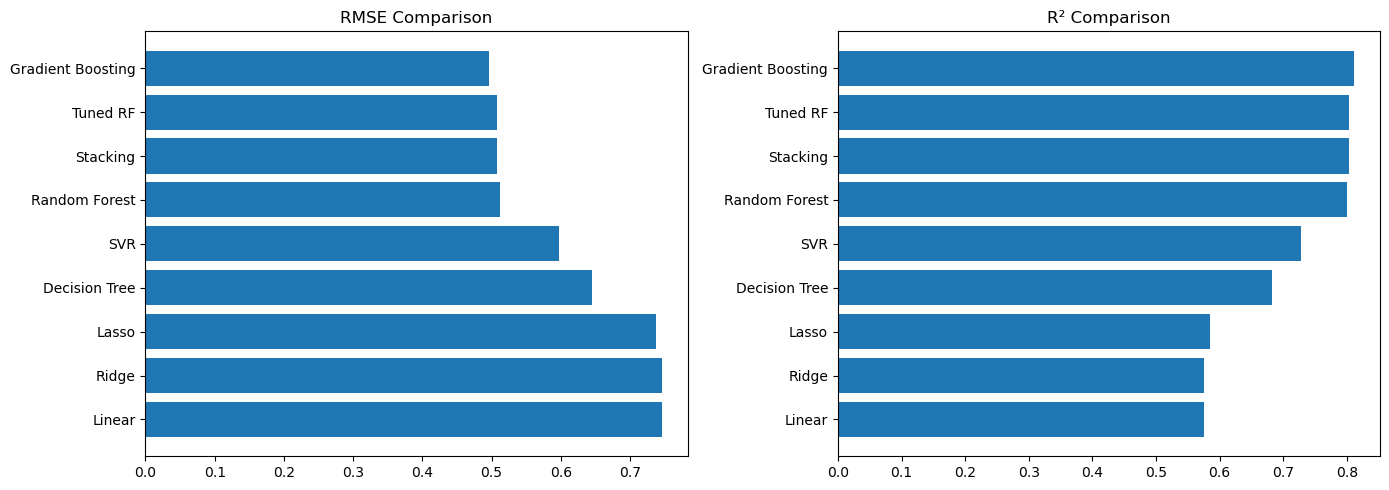

In [11]:
plt.figure(figsize=(14,5))

# RMSE
plt.subplot(1,2,1)
plt.barh(results["Model"], results["RMSE"])
plt.title("RMSE Comparison")
plt.gca().invert_yaxis()

# R2
plt.subplot(1,2,2)
plt.barh(results["Model"], results["R2"])
plt.title("R² Comparison")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()